<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[DenseNet-121] Epoch   1/100 | LR: 1.00e-04 | train loss 1.0756 acc 0.583 | val loss 0.5394 acc 0.793 *


[DenseNet-121] Epoch   2/100 | LR: 1.00e-04 | train loss 0.6909 acc 0.703 | val loss 0.4934 acc 0.810 *


[DenseNet-121] Epoch   3/100 | LR: 1.00e-04 | train loss 0.5153 acc 0.772 | val loss 0.4955 acc 0.810


[DenseNet-121] Epoch   4/100 | LR: 1.00e-04 | train loss 0.4486 acc 0.807 | val loss 0.4968 acc 0.810


...

[DenseNet-121] Epoch  13/100 | LR: 1.00e-04 | train loss 0.1688 acc 0.926 | val loss 0.4251 acc 0.880


[DenseNet-121] Epoch  14/100 | LR: 1.00e-04 | train loss 0.1903 acc 0.922 | val loss 0.3744 acc 0.866


[DenseNet-121] Epoch  15/100 | LR: 1.00e-05 | train loss 0.1298 acc 0.942 | val loss 0.4682 acc 0.854


[DenseNet-121] Epoch  16/100 | LR: 1.00e-05 | train loss 0.1198 acc 0.949 | val loss 0.4068 acc 0.873


[DenseNet-121] Epoch  17/100 | LR: 1.00e-05 | train loss 0.0907 acc 0.960 | val loss 0.4095 acc 0.876

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 17.

[DenseNet-121] Restored best checkpoint (val loss = 0.3546)


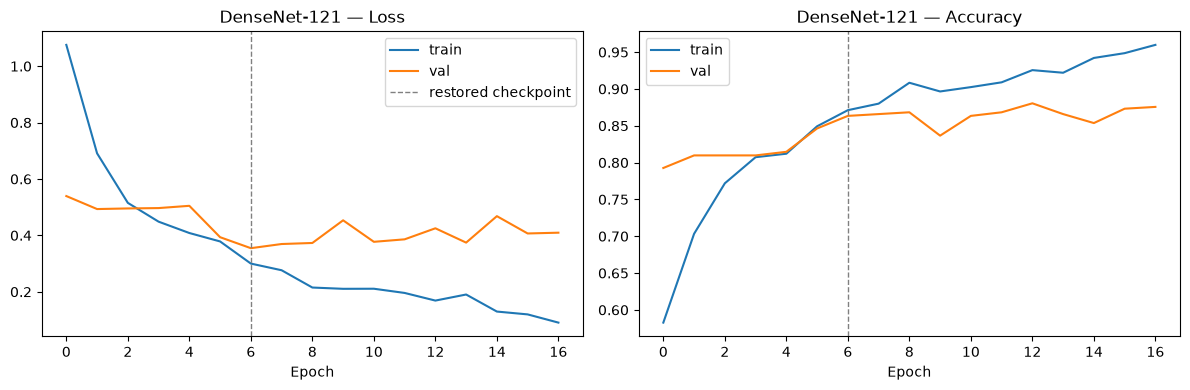

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.847


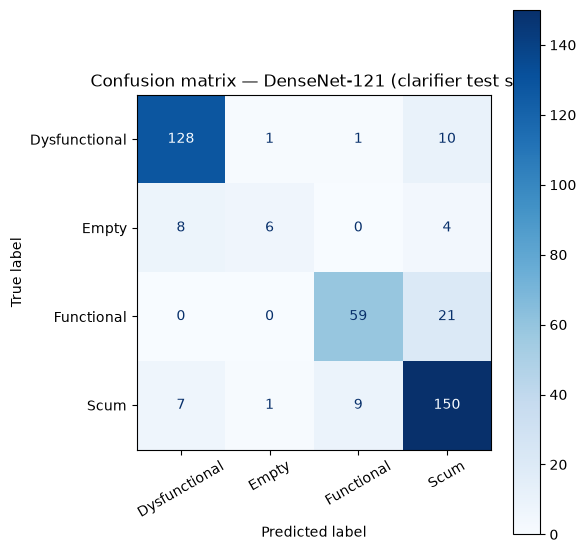

               precision    recall  f1-score   support

Dysfunctional      0.895     0.914     0.905       140
        Empty      0.750     0.333     0.462        18
   Functional      0.855     0.738     0.792        80
         Scum      0.811     0.898     0.852       167

     accuracy                          0.847       405
    macro avg      0.828     0.721     0.753       405
 weighted avg      0.846     0.847     0.841       405



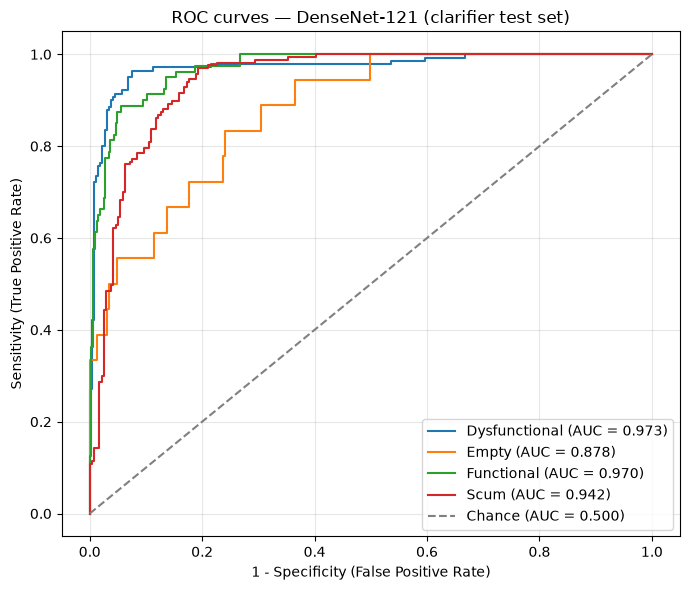

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.973
  Empty          : 0.878
  Functional     : 0.970
  Scum           : 0.942

Mean AUC (over 4/4 classes with test examples): 0.941


(np.float64(0.8469135802469135),
 {'Dysfunctional': 0.973477088948787,
  'Empty': 0.8778351995406259,
  'Functional': 0.9704230769230769,
  'Scum': 0.9418054647008505})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/results_clarifier_densenet121_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
